In [61]:
import pandas as pd
import matplotlib as plt
from metrics import metrics
from model import generics
pd.set_option('display.max_rows', 500)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
experiment_id = 'test'

In [63]:
df_mean_metrics.reset_index()['model'].unique()

array(['dt', 'dtinvp1', 'dtweakhigh0.15', 'mlpdiff', 'mlpdiffinvp1',
       'mlpdiffinvp2', 'mlpdiffinvp3', 'mlpweakhigh110', 'mlpweakhigh310',
       'mlpweakhigh510', 'svrdiff', 'svrdiffinvp1', 'svrdiffinvp2',
       'svrdiffinvp3', 'svrweakhigh0.115', 'svrweakhigh0.120',
       'svrweakhigh0.15', 'svrweakhigh0.320', 'svrweakhigh0.35',
       'svrweakhigh0.520', 'svrweakhigh0.55', 'svrweakhigh110',
       'svrweakhigh120', 'svrweakhigh310', 'svrweakhigh510',
       'v2mlpweakhigh0.115', 'v2mlpweakhigh0.120', 'v2mlpweakhigh0.15',
       'v2mlpweakhigh0.320', 'v2mlpweakhigh0.35', 'v2mlpweakhigh0.520',
       'v2mlpweakhigh0.55', 'v2mlpweakhigh110', 'v2mlpweakhigh310',
       'v2mlpweakhigh510', 'dtweakhigh0.110', 'lstm', 'dtinvp2'],
      dtype=object)

In [72]:
df_mean_metrics, df_all_metrics, df_prevs = metrics.open_fold_result(experiment_id)


df_selected = []
grouped = {
   'svr': ['svrdiff'],
   'svr_pert': [ 'svrdiffinvp1', 'svrdiffinvp2', 'svrdiffinvp3'],
    'svr_weak': ['svrweakhigh0.15','svrweakhigh110', 'svrweakhigh0.12', 'svrweakhigh0.18'
                 , 'svrweakhigh0.13', 'svrweakhigh0.14', 'svrweakhigh0.16', 'svrweakhigh0.17'
                 , 'svrweakhigh0.19', 'svrweakhigh0.111'
    ],
   'mlp': ['mlpdiff'],
   'mlp_pert': ['mlpdiffinvp1', 'mlpdiffinvp2', 'mlpdiffinvp3'],
    'mlp_weak': [
        'v2mlpweakhigh0.15', 'v2mlpweakhigh110', 'v2mlpweakhigh0.12', 'v2mlpweakhigh0.18'
        , 'v2mlpweakhigh0.12', 'v2mlpweakhigh0.13', 'v2mlpweakhigh0.14', 'v2mlpweakhigh0.16'
        , 'v2mlpweakhigh0.17', 'v2mlpweakhigh0.19', 'v2mlpweakhigh0.111'
        
    ],

}

for k, dft in df_mean_metrics.reset_index().groupby('ts'):
    display(dft)

    for key, gi in grouped.items():
        
        df_gi = dft[dft['model'].isin(gi)]
        best_model = int([df_gi['val_metric'].argmin()][0])
        serie_temp = df_gi.iloc[best_model].copy()
        serie_temp['model'] = key
        df_selected.append(serie_temp)


,ts,model,MSE,RMSE,MAPE,MAE,theil,ARV,IA,POCID,val_metric
0,Unemployment,dt,9847.136834,98.755816,12.553220,76.386458,1.338339,0.908675,0.751136,44.791667,74.845663
1,Unemployment,dtinvp1,10972.363964,102.969900,13.349333,79.991577,1.226057,0.990311,0.725716,50.625000,75.794886
2,Unemployment,dtinvp2,11109.091803,104.389644,13.832733,82.216279,0.976641,0.859858,0.739340,54.791667,76.963327
3,Unemployment,dtinvp3,11734.516830,107.501167,14.174904,85.091131,1.035869,0.987486,0.712687,54.583333,82.421928
4,Unemployment,dtinvp4,12206.086413,109.155769,13.639995,82.256672,1.334353,1.136694,0.690609,50.625000,84.732757
5,Unemployment,dtweakhigh0.110,5684.368386,75.394750,9.444288,56.635404,1.192356,0.636932,0.849191,58.333333,68.738961
6,Unemployment,dtweakhigh0.15,9429.004898,97.103063,12.618630,75.710160,1.389394,0.661166,0.790755,62.500000,66.208801
7,Unemployment,mlpdiff,1841.001273,42.902378,4.909958,30.282518,0.569239,0.194127,0.955721,71.041667,38.011432
8,Unemployment,mlpdiffinvp1,1780.709308,40.449176,5.021347,29.679691,0.364920,0.153599,0.961182,72.083333,28.059049
9,Unemployment,mlpdiffinvp2,1658.038793,38.837047,4.937778,28.758837,0.330192,0.134829,0.965021,72.500000,29.984197


,ts,model,MSE,RMSE,MAPE,MAE,theil,ARV,IA,POCID,val_metric
43,airlines,dt,973.321081,30.665076,5.174010,22.892857,0.364376,0.153279,0.959875,76.071429,19.104742
44,airlines,dtinvp1,1076.260303,32.344157,5.750101,24.937378,0.372684,0.155285,0.957579,73.928571,19.560245
45,airlines,dtinvp2,919.177329,29.876744,5.009341,22.181953,0.319055,0.141731,0.962726,79.285714,18.532190
46,airlines,dtinvp3,1159.854073,33.545627,5.665993,24.801311,0.378183,0.174277,0.953359,76.071429,19.238477
47,airlines,dtinvp4,1224.741248,34.378543,5.791620,25.739164,0.363428,0.166620,0.952968,75.000000,19.562456
48,airlines,dtweakhigh0.110,1782.591031,42.220742,6.188003,27.927440,0.418203,0.205508,0.937183,71.428571,16.334842
49,airlines,dtweakhigh0.15,1138.000000,33.734256,5.123884,23.857143,0.436529,0.216153,0.947929,75.000000,15.740076
50,airlines,lstm,3956.540726,61.014430,11.540998,51.309040,4.043493,0.754098,0.806422,71.428571,39.402115
51,airlines,mlpdiff,341.531036,18.479416,3.333146,14.161261,0.112417,0.051104,0.986604,88.571429,8.818228
52,airlines,mlpdiffinvp1,284.750425,16.874131,2.985193,12.690808,0.100116,0.042591,0.988848,86.785714,8.500383


,ts,model,MSE,RMSE,MAPE,MAE,theil,ARV,IA,POCID,val_metric
87,coloradoRiver,dt,0.507201,0.705082,95.242720,0.393252,0.666364,0.830579,0.702096,49.459459,0.838914
88,coloradoRiver,dtinvp1,0.540893,0.733185,109.674354,0.414806,0.721343,0.942009,0.660578,48.918919,0.922813
89,coloradoRiver,dtinvp2,0.781790,0.871265,128.020253,0.498020,0.721588,0.962387,0.603427,49.121622,0.974961
90,coloradoRiver,dtinvp3,0.682071,0.821270,120.250566,0.518068,0.695151,0.951992,0.617640,49.662162,1.008987
91,coloradoRiver,dtinvp4,0.766758,0.870007,140.370064,0.544682,0.633595,0.917058,0.608999,47.770270,1.045618
92,coloradoRiver,dtweakhigh0.110,0.475727,0.689729,62.700107,0.357301,0.503212,0.808937,0.711188,60.135135,0.834114
93,coloradoRiver,dtweakhigh0.15,0.593206,0.770199,116.815732,0.489272,0.508758,0.935902,0.644710,48.648649,0.773259
94,coloradoRiver,lstm,0.394104,0.627251,117.578875,0.369896,0.921869,1.152017,0.676285,61.554054,0.718858
95,coloradoRiver,mlpdiff,0.241131,0.491034,74.194168,0.265617,1.012583,0.762005,0.808185,63.716216,0.767605
96,coloradoRiver,mlpdiffinvp1,0.223089,0.472087,74.007513,0.270642,1.354334,0.860622,0.807719,67.027027,0.734292


,ts,model,MSE,RMSE,MAPE,MAE,theil,ARV,IA,POCID,val_metric
131,milk,dt,250.719491,14.852067,0.989152,8.508402,0.193709,0.088311,0.979429,89.354839,9.582565
132,milk,dtinvp1,295.605253,16.730163,1.246095,10.680018,0.215131,0.085104,0.977991,87.419355,10.430945
133,milk,dtinvp2,195.699819,13.420488,1.071049,9.164303,0.155819,0.062999,0.984662,90.322581,10.377120
134,milk,dtinvp3,266.614348,15.750685,1.300258,11.025787,0.205032,0.084431,0.979218,85.161290,10.061899
135,milk,dtinvp4,219.287079,13.893643,1.123960,9.577005,0.182009,0.072134,0.982565,90.645161,10.232578
136,milk,dtweakhigh0.110,223.112482,14.936950,1.323545,11.186619,0.170687,0.067019,0.983134,83.870968,7.613233
137,milk,dtweakhigh0.15,141.752618,11.905991,1.023732,8.673526,0.095852,0.040042,0.989670,83.870968,7.780965
138,milk,lstm,362.076455,18.241396,1.603271,13.682740,0.302296,0.104484,0.972588,89.677419,24.224640
139,milk,mlpdiff,35.908368,5.988933,0.591665,4.956601,0.032799,0.010892,0.997309,95.806452,7.556126
140,milk,mlpdiffinvp1,37.978825,6.154336,0.583644,4.888115,0.034890,0.011496,0.997156,95.806452,7.503835


,ts,model,MSE,RMSE,MAPE,MAE,theil,ARV,IA,POCID,val_metric
175,ozon,dt,1.888644,1.365467,23.241464,1.064308,0.620522,0.493314,0.877588,60.833333,1.226595
176,ozon,dtinvp1,2.132766,1.455373,24.298445,1.134421,0.634552,0.492969,0.868549,60.555556,1.319293
177,ozon,dtinvp2,2.507075,1.580104,28.614064,1.256886,0.653428,0.546854,0.847771,59.722222,1.332192
178,ozon,dtinvp3,2.258092,1.487614,27.071398,1.202980,0.693423,0.549037,0.856824,58.333333,1.309679
179,ozon,dtinvp4,2.286251,1.504613,26.721735,1.185626,0.601312,0.507396,0.860833,62.222222,1.315609
180,ozon,dtweakhigh0.110,2.554541,1.598293,31.424113,1.243161,1.074013,0.675680,0.834331,52.777778,1.039414
181,ozon,dtweakhigh0.15,1.792014,1.338661,25.911584,1.049310,0.805669,0.536256,0.875617,63.888889,1.084002
182,ozon,lstm,0.699034,0.835723,15.775063,0.666646,0.596333,0.186112,0.956256,86.388889,1.009464
183,ozon,mlpdiff,0.901680,0.949558,18.321107,0.780155,0.609108,0.232767,0.944117,80.277778,1.079362
184,ozon,mlpdiffinvp1,0.933301,0.966068,18.119340,0.785874,0.592710,0.238192,0.942400,80.555556,1.083976


,ts,model,MSE,RMSE,MAPE,MAE,theil,ARV,IA,POCID,val_metric
219,pollution,dt,1.008982e+06,994.603466,24.342606,791.639627,0.982014,1.278688,0.618867,55.000000,539.453579
220,pollution,dtinvp1,9.494432e+05,966.867380,23.528002,762.907158,0.873944,1.210010,0.640926,61.153846,539.302986
221,pollution,dtinvp2,7.402706e+05,852.981716,20.140188,660.826598,0.734541,0.998954,0.718999,65.769231,559.054567
222,pollution,dtinvp3,9.937426e+05,987.365031,24.927548,804.192302,1.039745,1.288969,0.611175,58.846154,559.185426
223,pollution,dtinvp4,9.284502e+05,959.301189,23.095460,762.045500,0.998161,1.230114,0.638631,57.307692,551.996914
224,pollution,dtweakhigh0.110,1.509450e+06,1228.596687,25.415207,890.930328,1.114254,1.624746,0.504075,46.153846,458.737859
225,pollution,dtweakhigh0.15,5.761777e+05,759.063672,15.881525,543.240231,0.390161,0.584605,0.810240,69.230769,479.898087
226,pollution,lstm,1.252408e+06,1118.843641,25.532056,869.210379,6.356998,2.912750,0.373512,26.153846,635.399534
227,pollution,mlpdiff,4.879494e+05,698.439308,19.144100,559.223979,0.328223,0.690811,0.816399,75.000000,469.397648
228,pollution,mlpdiffinvp1,4.689661e+05,684.684854,18.655960,560.984737,0.350745,0.677822,0.824541,73.076923,469.096014


,ts,model,MSE,RMSE,MAPE,MAE,theil,ARV,IA,POCID,val_metric
263,redwine,dt,3.633237e+05,599.235955,22.585416,456.855618,0.720732,0.940270,0.741803,58.108108,367.365779
264,redwine,dtinvp1,3.230296e+05,566.501609,21.491297,446.726564,0.601389,0.826019,0.772782,55.945946,372.552318
265,redwine,dtinvp2,3.610646e+05,598.045565,23.372150,467.285163,0.807499,0.957274,0.736667,54.054054,367.049845
266,redwine,dtinvp3,4.014982e+05,628.639474,24.169967,489.654242,0.765543,1.060434,0.701658,53.783784,381.830500
267,redwine,dtinvp4,3.669393e+05,603.787663,23.114787,454.695522,0.732202,0.989058,0.733768,53.783784,374.391555
268,redwine,dtweakhigh0.110,4.972610e+05,705.167361,30.628102,533.174235,0.888748,1.336332,0.635975,45.945946,294.920969
269,redwine,dtweakhigh0.15,3.312947e+05,575.582017,20.767520,398.657451,0.598628,0.758943,0.779985,64.864865,298.673526
270,redwine,mlpdiff,1.245451e+05,352.605795,13.042098,265.312334,0.351725,0.397321,0.909377,65.675676,238.028426
271,redwine,mlpdiffinvp1,1.534813e+05,384.292840,14.263287,293.815807,0.390515,0.493862,0.884306,66.486486,248.306599
272,redwine,mlpdiffinvp2,1.508640e+05,380.869308,14.099837,289.268352,0.386000,0.502911,0.885064,67.567568,239.335243


,ts,model,MSE,RMSE,MAPE,MAE,theil,ARV,IA,POCID,val_metric
306,sunspot,dt,784.316491,27.762702,44.382189,20.314269,0.802148,0.508158,0.898933,74.736842,17.828462
307,sunspot,dtinvp1,1063.267294,32.269902,50.306855,23.137296,0.877988,0.642830,0.866047,73.859649,19.095943
308,sunspot,dtinvp2,1011.222890,31.640919,51.086244,22.964496,0.844957,0.582623,0.875129,73.157895,19.861759
309,sunspot,dtinvp3,954.641040,30.822948,51.994474,22.669415,0.768362,0.530910,0.883945,75.263158,20.106799
310,sunspot,dtinvp4,957.440193,30.858006,57.055196,22.944103,0.859598,0.585062,0.879341,72.631579,20.055776
311,sunspot,dtweakhigh0.110,1035.958777,32.186314,45.922508,23.464992,1.353522,0.780246,0.853970,82.456140,13.866935
312,sunspot,dtweakhigh0.15,747.884746,27.347482,44.305706,20.398794,0.823954,0.480589,0.905092,75.438596,14.000267
313,sunspot,lstm,383.574371,19.540045,30.691316,14.444702,0.356782,0.177520,0.958882,89.122807,11.868828
314,sunspot,mlpdiff,567.810268,23.788137,36.332309,17.723941,0.568074,0.294805,0.934673,82.631579,12.407753
315,sunspot,mlpdiffinvp1,577.456355,24.004054,34.574601,17.768638,0.587559,0.306492,0.932810,84.561404,12.217131


,ts,model,MSE,RMSE,MAPE,MAE,theil,ARV,IA,POCID,val_metric
350,temperature,dt,11.925573,3.443255,5.731901,2.736858,0.395254,0.179656,0.954562,67.500000,3.460720
351,temperature,dtinvp1,11.646068,3.367446,5.487769,2.621253,0.377730,0.156783,0.958103,70.625000,3.409425
352,temperature,dtinvp2,12.979981,3.580257,6.189502,2.935628,0.382454,0.177044,0.952732,68.333333,3.640414
353,temperature,dtinvp3,12.825116,3.567590,6.012908,2.868872,0.384744,0.174748,0.953428,67.916667,3.588731
354,temperature,dtinvp4,12.855718,3.570325,6.041625,2.875015,0.383628,0.170352,0.954032,68.750000,3.661520
355,temperature,dtweakhigh0.110,8.876766,2.979390,4.583193,2.117672,0.312355,0.119680,0.968190,79.166667,3.039275
356,temperature,dtweakhigh0.15,11.019903,3.319624,5.840033,2.807926,0.349378,0.148901,0.960390,60.416667,2.912209
357,temperature,lstm,5.495494,2.341363,4.201187,1.931484,0.288205,0.079432,0.979830,77.083333,2.914689
358,temperature,mlpdiff,5.268848,2.295171,3.999013,1.817455,0.258571,0.076503,0.980648,77.083333,2.613127
359,temperature,mlpdiffinvp1,5.320485,2.306402,3.965738,1.794727,0.258217,0.077298,0.980450,77.083333,2.597039


In [69]:
pd.DataFrame(df_selected)#.to_csv('test.csv')

,ts,model,MSE,RMSE,MAPE,MAE,theil,ARV,IA,POCID,val_metric
13,Unemployment,svr,2.621499e+03,51.200571,6.038365,37.494731,0.716959,0.270607,0.936612,68.750000,38.654166
14,Unemployment,svr_pert,1.726033e+03,41.545550,5.071211,30.627085,0.456165,0.177108,0.959084,81.250000,29.831062
26,Unemployment,svr_weak,1.329951e+03,36.468494,4.568085,26.930351,0.479479,0.152115,0.967145,77.083333,32.993828
6,Unemployment,mlp,1.841001e+03,42.902378,4.909958,30.282518,0.569239,0.194127,0.955721,71.041667,38.011432
9,Unemployment,mlp_pert,1.116379e+03,33.402405,4.199232,24.498976,0.299510,0.102822,0.975167,73.958333,26.955298
39,Unemployment,mlp_weak,1.292167e+03,35.946724,4.450452,26.520789,0.406423,0.125071,0.970442,72.916667,30.318413
56,airlines,svr,3.794372e+02,19.479148,3.773001,16.038753,0.124398,0.060941,0.984545,85.714286,11.021807
59,airlines,svr_pert,9.331710e+02,30.547847,5.627242,23.929591,0.188209,0.117875,0.966197,82.142857,12.699946
61,airlines,svr_weak,3.323327e+02,18.229996,3.235602,13.940003,0.131860,0.055928,0.986166,82.142857,11.218400
49,airlines,mlp,3.415310e+02,18.479416,3.333146,14.161261,0.112417,0.051104,0.986604,88.571429,8.818228


Unemployment
airlines
coloradoRiver
lakeerie
lynx
milk
ozon
pollution
redwine
sunspot
temperature


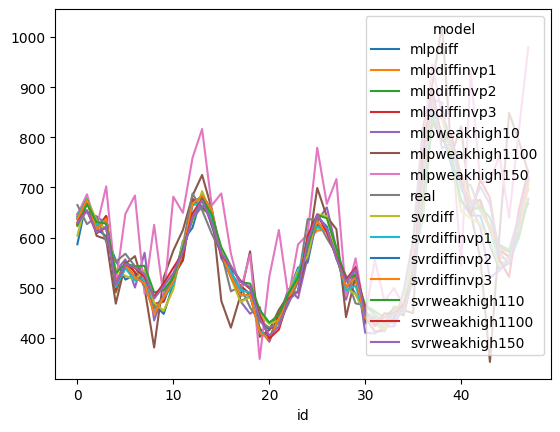

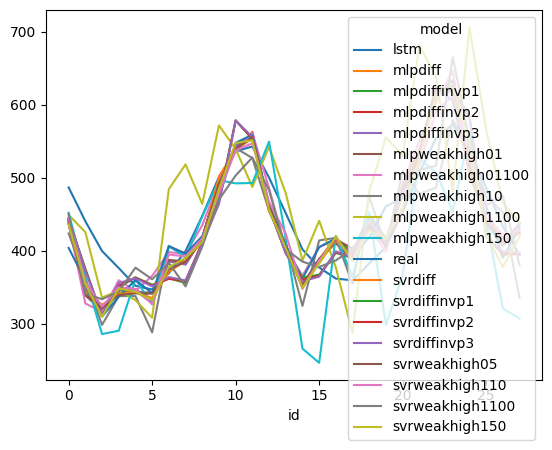

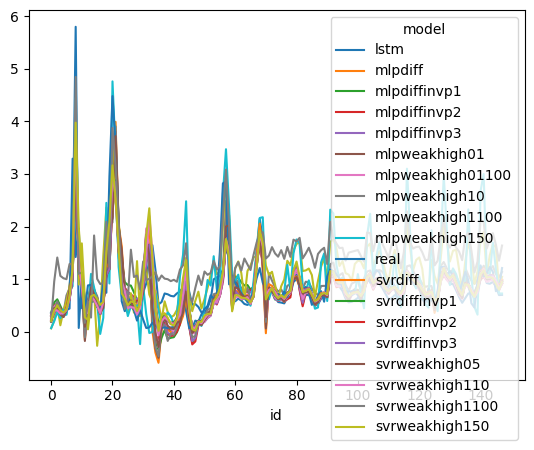

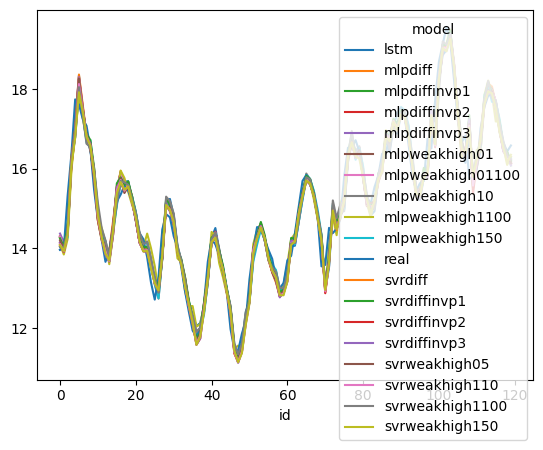

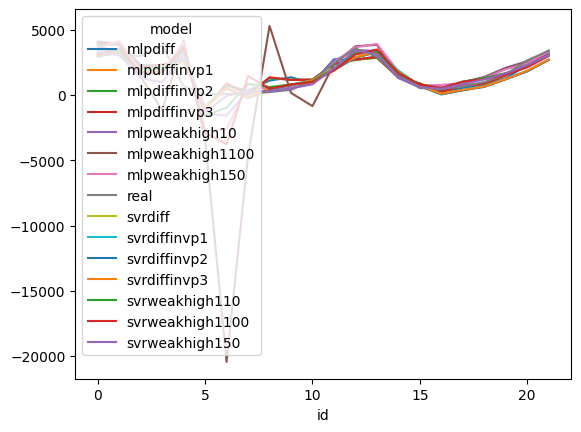

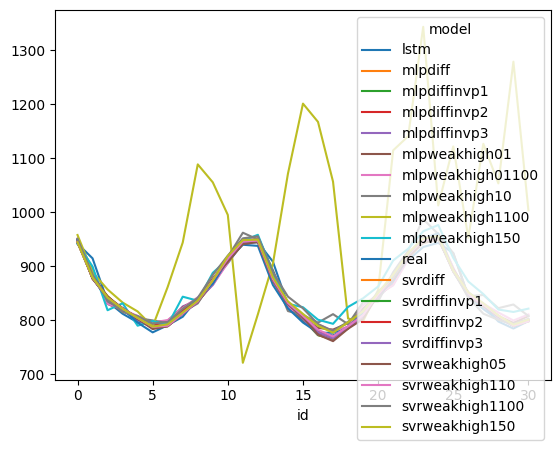

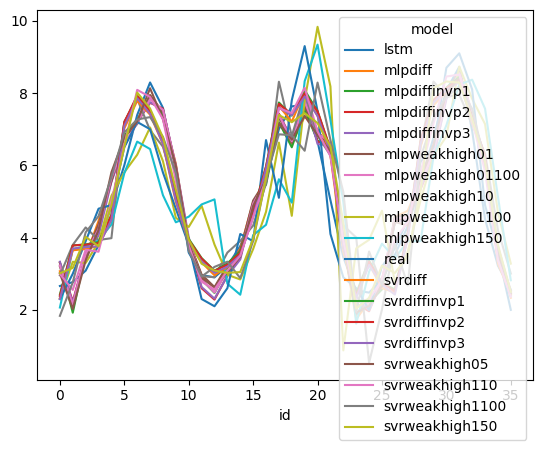

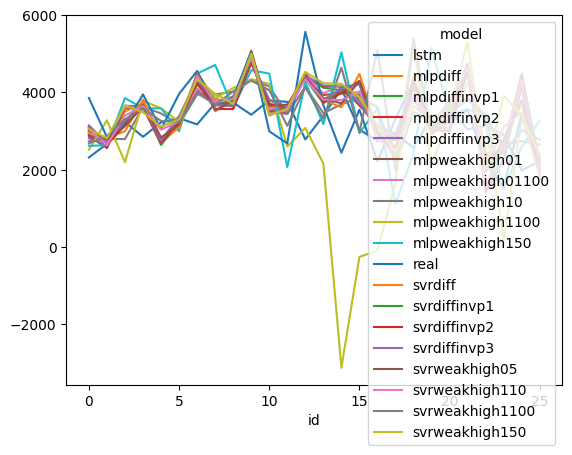

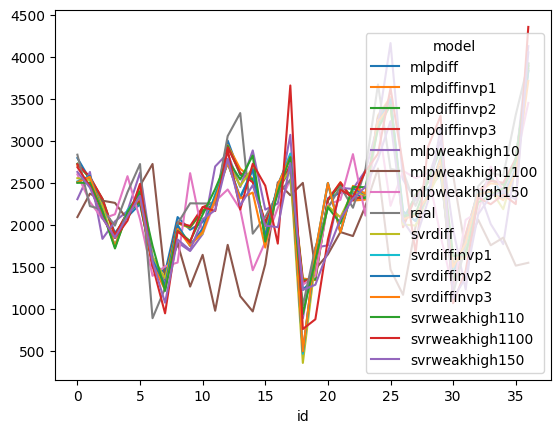

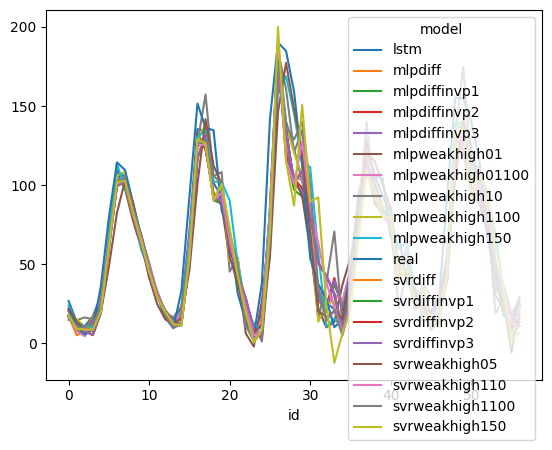

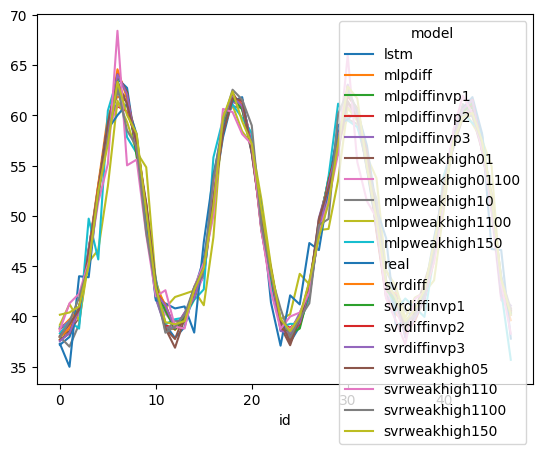

In [5]:
for key, dfp in df_prevs.groupby('ts'):
    print(key)
    dfp.pivot( columns = 'model', index='id', values='prev').plot()

In [6]:
_, pth = generics.format_names(experiment_id, base_name='pollution', model_name= 'mlpweakhigh')
generics.open_saved_result(pth)


FileNotFoundError: [Errno 2] No such file or directory: '/home/domingossj/experiments/data/result/test/pollution_mlpweakhigh.pkl'